# Escalated case: does the story survive when revenue counts only the orders that reached customers and stayed?

**Week 1, Tuesday afternoon. The escalated case, unguided, fifty minutes.** The morning climbed six
chapters on booked orders, every order placed before any cancellation or return. On them revenue fell
11.0 percent between two closed quarters, Rs 2,10,00,000 to Rs 1,87,00,000, while customers held at
69 and orders per customer fell from 1.65 to 1.25.
This case climbs the same ladder alone, on a harder definition, where one
branch that held in the morning moves.

The board pack is the set of numbers Kalpa's board reads every quarter.

> **The client asks.** "The board pack reports revenue on orders that reached the customer and
> stayed there. Monday you taught me that cancelled orders are not sales. Does your story survive on
> delivered orders? Which branch, which segment, and what would you bet on?"
>
> Meera Raghavan, CEO, Kalpa Retail

**Who needs the answer.** Meera Raghavan, the CEO, takes revenue to the board on the board pack's
definition, so before the morning's story reaches the board she needs to know whether each rung of it
holds on orders that reached the customer and stayed there. If a rung does not hold and nobody says
so, the board acts on a story its own numbers do not support, and next quarter's money follows it.

**The questions on the way.**

1. Is the delivered drop real?
2. Which branch moves on delivered orders?
3. Are those lost customers?
4. Which segment moves on delivered orders?
5. Is the delivered rise mix or rate?
6. What does the sentence to Meera say on delivered orders?

> **Kavya's review of the morning.** "Every number you gave Meera this morning was on booked orders.
> Change the definition and rerun every rung. If a branch that held starts to move, find out what it
> is made of before anyone else names it."

This is the solution twin: every placeholder is filled, every cell has run, and under each step a
line says why the other three options fail.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Business", "Student"]


def tree_for(rows):
    """The revenue tree's leaves for any list of orders, returned as a dictionary (chapter 3)."""
    revenue = 0
    seen = {}
    for order in rows:
        revenue += order["amount"]
        seen[order["customer_id"]] = True
    orders = len(rows)
    customers = len(seen)
    return {"revenue": revenue, "orders": orders, "customers": customers,
            "orders_per_customer": orders / customers if customers else 0,
            "revenue_per_order": revenue / orders if orders else 0}


def pct_change(before, after):
    """Chapter 5's fixed helper: the change every time, in the same type."""
    return round(100 * (after - before) / before, 1)

print(len(ORDERS), "booked orders loaded")

200 booked orders loaded


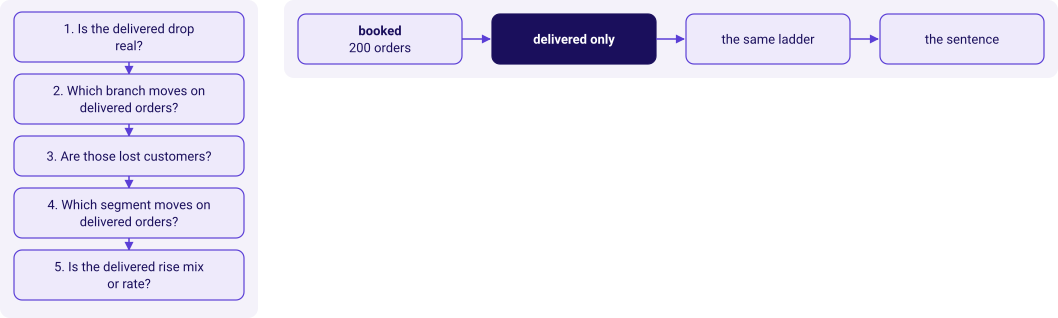

In [2]:
kit.side_by_side(
    kit.ladder(['Is the delivered drop real?', 'Which branch moves on delivered orders?', 'Are those lost customers?', 'Which segment moves on delivered orders?', 'Is the delivered rise mix or rate?'], show=False),
    kit.flow(["booked\n200 orders", "delivered only", "the same ladder", "the sentence"], lit=1, show=False),
)

## Part 1. Is the delivered drop real?

Keep only the orders that reached the customer and stayed, then compare the two closed quarters.

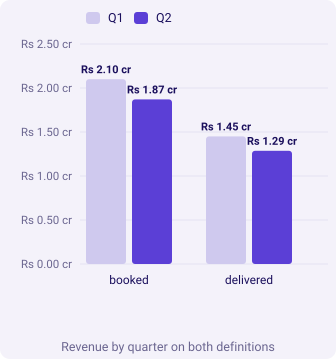

In [3]:
delivered = []
for order in ORDERS:
    # TODO 1. Which condition keeps the orders that reached the customer and stayed there?
    #   a) order["status"] != "cancelled"
    #   b) order["status"] == "delivered"
    #   c) order["status"] in ("delivered", "returned")
    #   d) order["amount"] > 0
    if order["status"] == "delivered":
        delivered.append(order)
dq = {q: [o for o in delivered if o["quarter"] == q] for q in ("Q1", "Q2")}
d1, d2 = tree_for(dq["Q1"]), tree_for(dq["Q2"])
d_change = pct_change(d1["revenue"], d2["revenue"])
kit.columns(["booked", "delivered"], [("Q1", [21000000, d1["revenue"]]), ("Q2", [18700000, d2["revenue"]])],
            fmt=lambda v: f"Rs {v / 1e7:.2f} cr", title="Revenue by quarter on both definitions")
kit.check("138 of the 200 orders were delivered", len(delivered) == 138, f"{len(delivered)}")
by_month = {}
for o in delivered:
    by_month[o["order_date"][:7]] = by_month.get(o["order_date"][:7], 0) + o["amount"]
q1_months = sum(v for m, v in by_month.items() if m <= "2026-06")
kit.check("the delivered change matches a second route by month", d_change == pct_change(q1_months, sum(by_month.values()) - q1_months), f"{d_change}")

**Why the other three fail.** a) keeps returned orders, which reached the customer and came back.
c) keeps them on purpose. d) keeps every order, since every amount is positive, which is the booked
file again.

**Item 1 in your brief** asks which figure answers Meera. The fall on delivered orders is
Rs 16,40,290, 11.3 percent, on two closed quarters of thirteen weeks: the drop survives the
definition.

## Part 2. Which branch moves on delivered orders?

Put rupees on each branch with the bridge in the tree's order: customers first, then orders per
customer, then revenue per order.

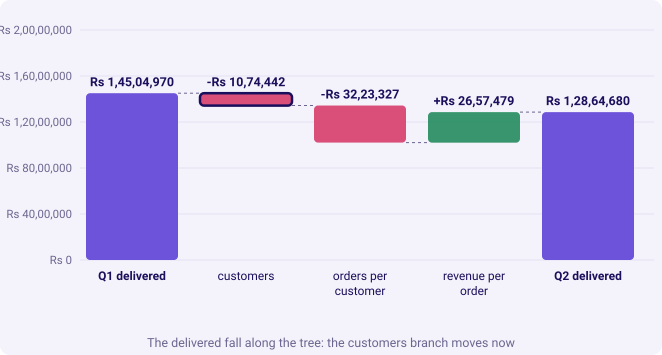

In [4]:
c1, f1, v1 = d1["customers"], d1["orders_per_customer"], d1["revenue_per_order"]
c2, f2, v2 = d2["customers"], d2["orders_per_customer"], d2["revenue_per_order"]
# TODO 2. Which expression is the customers step of the bridge?
#   a) (c2 - c1) * f1 * v1
#   b) c2 * (f2 - f1) * v1
#   c) (c2 - c1) * f2 * v2
#   d) (c2 - c1) / c1
move_customers = (c2 - c1) * f1 * v1
move_frequency = c2 * (f2 - f1) * v1
move_value = c2 * f2 * (v2 - v1)
kit.bridge(("Q1 delivered", d1["revenue"]), [("customers", round(move_customers)), ("orders per customer", round(move_frequency)),
           ("revenue per order", round(move_value))], end_label="Q2 delivered", lit=[0],
           title="The delivered fall along the tree: the customers branch moves now")
kit.check("the bridge lands on Q2 delivered revenue", abs(d1["revenue"] + move_customers + move_frequency + move_value - d2["revenue"]) < 1)
kit.check("the delivered customer counts match the file", (c1, c2) == (54, 50), f"{c1} and {c2}")

**Why the other three fail.** b) is the frequency step. c) prices the lost customers at Q2's leaves,
which charges them for the overlap and breaks the order the bridge promised. d) is a rate, which does
not add along a bridge in rupees.

**Item 2 in your brief.** On delivered orders the customers branch takes Rs 10,74,442, frequency
Rs 32,23,327, and revenue per order gives back Rs 26,57,479. Marketing will read the first number as
lost customers. Part 3 finds out what it is.

## Part 3. Are those lost customers?

Four fewer customers had a delivered order in Q2. The morning showed all 69 customers booked in both
quarters. Compare the two views.

In [5]:
booked_ids = {q: {o["customer_id"] for o in ORDERS if o["quarter"] == q} for q in ("Q1", "Q2")}
deliv_ids = {q: {o["customer_id"] for o in dq[q]} for q in ("Q1", "Q2")}
# TODO 3. Marketing will call the customers who dropped out of the delivered count lost. Which set holds
# the ones among them who still placed an order in Q2?
#   a) deliv_ids["Q1"] & booked_ids["Q2"]
#   b) booked_ids["Q1"] - booked_ids["Q2"]
#   c) (deliv_ids["Q1"] - deliv_ids["Q2"]) & booked_ids["Q2"]
#   d) deliv_ids["Q2"] - deliv_ids["Q1"]
still_booked = (deliv_ids["Q1"] - deliv_ids["Q2"]) & booked_ids["Q2"]
print(len(still_booked), "customers in your set")

19 customers in your set


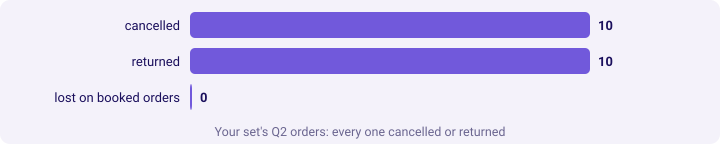

Their Q2 orders ended as,Orders
cancelled,10
returned,10


In [6]:
their_q2 = {}
for o in ORDERS:
    if o["quarter"] == "Q2" and o["customer_id"] in still_booked:
        their_q2[o["status"]] = their_q2.get(o["status"], 0) + 1
kit.bars([(status, n) for status, n in sorted(their_q2.items())] + [("lost on booked orders", len(booked_ids["Q1"] - booked_ids["Q2"]))],
         title="Your set's Q2 orders: every one cancelled or returned")
kit.table(["Their Q2 orders ended as", "Orders"], sorted(their_q2.items()), caption="What happened to your set's Q2 orders")
kit.check("your set placed orders in Q2", sum(their_q2.values()) > 0, f"{sum(their_q2.values())} orders")
kit.check("none of your set's Q2 orders counts as delivered", their_q2.get("delivered", 0) == 0)

**Why the other three fail.** a) is every delivered Q1 customer who booked in Q2, 54 people,
including those whose Q2 orders were delivered. b) is the booked churn, which is empty. d) is the
customers delivered in Q2 and not Q1, the other side of the overlap.

**Item 3 in your brief.** The customers branch on delivered orders is cancellations and returns: the
19 customers who "disappeared" all ordered in Q2, and their orders were cancelled or returned. Split
by reason, those orders go to the teams that own fulfilment, getting orders to customers intact, and
the product, and Marketing's Rs 12 crore still has no lost customer to replace.

## Part 4. Which segment moves on delivered orders?

Run `tree_for` per segment on delivered orders, roll the rate up to the company, and count the groups
that come back.

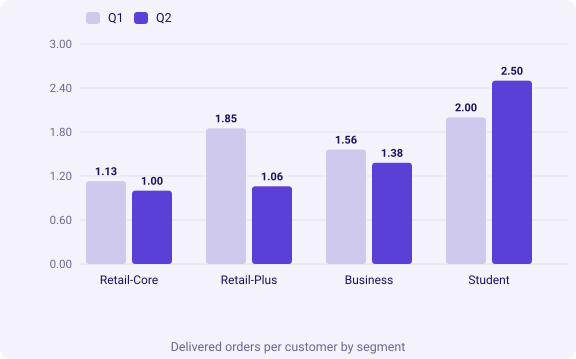

In [7]:
seg1 = {s: tree_for([o for o in dq["Q1"] if o["segment"] == s]) for s in SEGMENTS}
seg2 = {s: tree_for([o for o in dq["Q2"] if o["segment"] == s]) for s in SEGMENTS}
averaged = {q: sum(t["orders_per_customer"] for t in seg.values()) / 4 for q, seg in (("Q1", seg1), ("Q2", seg2))}
# TODO 4. Which roll-up gives the company's delivered orders per customer from the segments?
#   a) sum(t["orders_per_customer"] for t in seg.values()) / 4
#   b) sum(t["customers"] for t in seg.values()) / sum(t["orders"] for t in seg.values())
#   c) sorted(t["orders_per_customer"] for t in seg.values())[2]
#   d) sum(t["orders"] for t in seg.values()) / sum(t["customers"] for t in seg.values())
def roll_up(seg):
    return sum(t["orders"] for t in seg.values()) / sum(t["customers"] for t in seg.values())
weighted = {"Q1": roll_up(seg1), "Q2": roll_up(seg2)}
changes = {s: pct_change(seg1[s]["orders_per_customer"], seg2[s]["orders_per_customer"]) for s in SEGMENTS}
kit.columns(SEGMENTS, [("Q1", [round(seg1[s]["orders_per_customer"], 2) for s in SEGMENTS]),
                       ("Q2", [round(seg2[s]["orders_per_customer"], 2) for s in SEGMENTS])],
            fmt=lambda v: f"{v:.2f}", title="Delivered orders per customer by segment")
kit.check("the roll-up reproduces the company figure", abs(weighted["Q1"] - d1["orders_per_customer"]) < 1e-9 and abs(weighted["Q2"] - d2["orders_per_customer"]) < 1e-9)
kit.check("averaging the averages gives a different figure", pct_change(averaged["Q1"], averaged["Q2"]) != pct_change(d1["orders_per_customer"], d2["orders_per_customer"]))
# TODO 5. Which test proves that no segment came back without a number?
#   a) None not in summary.values() and len(summary) == 4
#   b) min(summary.values()) < 0 and len(summary) > 0
#   c) "Business" in summary and len(summary) == 4
#   d) len(summary) == 4 and "Retail-Core" in summary
def all_numbers(summary):
    return None not in summary.values() and len(summary) == 4


broken = {"Retail-Core": -5.3, "Retail-Plus": None, "Business": -15.0, "Student": None}   # invented, last quarter's shape
try:
    catches = all_numbers(broken) is False
except TypeError:
    catches = False
kit.check("the test passes on today's four changes", all_numbers(changes) is True)
kit.check("the test fails on the invented broken summary", catches)
kit.check("every segment has its change on delivered orders", len(changes) == 4)

**Why the other three fail.** TODO 4: a) is the average of averages, minus 9.2 percent against the
true minus 24.0. b) is the reciprocal, customers per order. c) ignores every segment's size. TODO 5:
b) raises a TypeError on a None and reports nothing. c) and d) look for one segment by name and pass
on the broken summary.

**Item 4 in your brief.** On delivered orders Retail-Plus falls furthest again, 1.85 to 1.06 orders
per member, minus 42.6 percent; Business and Retail-Core fall about 11.5 percent each; Student rises.
The segment survives the definition.

## Part 5. Is the delivered rise mix or rate?

Delivered revenue per order rose 26.0 percent. Split it the way chapter 4 did: price Q2's mix at Q1's
segment rates.

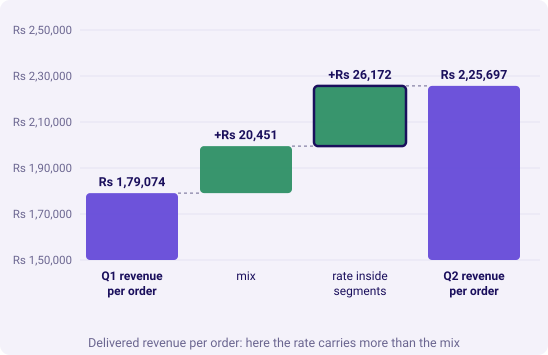

In [8]:
share1 = {s: seg1[s]["orders"] / d1["orders"] for s in SEGMENTS}
share2 = {s: seg2[s]["orders"] / d2["orders"] for s in SEGMENTS}
at_q2_mix = 0
for s in SEGMENTS:
    # TODO 6. What adds up to revenue per order at Q2's mix and Q1's segment rates?
    #   a) share1[s] * seg2[s]["revenue_per_order"]
    #   b) share2[s] * seg1[s]["revenue_per_order"]
    #   c) share2[s] * seg2[s]["revenue_per_order"]
    #   d) (seg1[s]["revenue_per_order"] + seg2[s]["revenue_per_order"]) / 2
    at_q2_mix += share2[s] * seg1[s]["revenue_per_order"]
mix, rate = at_q2_mix - v1, v2 - at_q2_mix
kit.bridge(("Q1 revenue per order", round(v1)), [("mix", round(mix)), ("rate inside segments", round(rate))],
           end_label="Q2 revenue per order", lo=150000, fmt=kit.rupees, lit=[1],
           title="Delivered revenue per order: here the rate carries more than the mix")
kit.check("mix and rate add back to the whole rise", abs(mix + rate - (v2 - v1)) < 1e-6)
kit.check("on delivered orders the mix explains 44 percent", round(mix / (v2 - v1) * 100) == 44, f"{mix / (v2 - v1) * 100:.1f}")

**Why the other three fail.** a) prices Q1's mix at Q2's rates, which measures the rate part. c) is
Q2's actual revenue per order. d) averages two rates and weights no segment, the average of averages
again.

**Item 5 in your brief.** On booked orders the mix explained 69 percent of the rise; on delivered
orders 44 percent, because Business's delivered orders grew in size, from Rs 10,24,651 to
Rs 11,60,405 each on average. The definition moved the split, and the consumer segments still paid
about the same, so the consumer business shows no price signal on either definition.

## What does the sentence to Meera say on delivered orders?

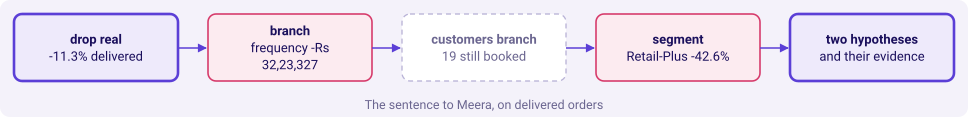

In [9]:
# TODO 7. Which segment leads the sentence as the behaviour finding on delivered orders?
#   a) "Business"
#   b) "Student"
#   c) "all four segments"
#   d) "Retail-Plus"
lead = "Retail-Plus"
kit.check("your lead matches a second route over the segment changes", lead in changes and lead == min(changes, key=changes.get))
kit.flow([f"drop real\n{d_change}% delivered", f"branch\nfrequency {kit.rupees(round(move_frequency))}",
          f"customers branch\n{len(still_booked)} still booked", f"segment\n{lead} {changes.get(lead, '?')}%", "two hypotheses\nand their evidence"],
         kinds=["known", "bad", "unknown", "bad", "known"], title="The sentence to Meera, on delivered orders")

**Why the other three fail.** a) is the rupee finding on three lumpy orders. b) rose. c) spreads a
fall that sits in one segment across four.

**The sentence.** "On delivered orders the story holds: revenue fell 11.3 percent between closed
quarters, and frequency carries the most rupees, Rs 32,23,327. Four fewer customers had a delivered
order, but all 19 who dropped out of the delivered count booked again in Q2 and saw their orders
cancelled or returned, so that branch is cancellations and returns, to be split by reason, with no
lost customer for acquisition to replace. Retail-Plus members ordered 42.6 percent less often. The
two hypotheses stand as this morning: the reorder button after 25 August, settled by the app's logs,
and a change for members in July, settled by the tier's change log."

### In the interview: what do you do when a new definition of revenue moves a branch that held?

**[D] You change the definition of revenue and a branch that held starts to move; what do you do?**
"I decompose the new movement before anyone names it. Here customers with a delivered order fell from
54 to 50, which looks like churn, but every one of the 19 who left the delivered count booked again
and had orders cancelled or returned. So the branch is cancellations and returns, which I would
split by reason. I show both definitions side by side and say which owner each branch goes to." The interviewer is listening for the definition named
and the moved branch explained.

In [10]:
kit.check_summary()
print("Answer string for the TODOs: b a c d a b d.")

Answer string for the TODOs: b a c d a b d.
